Device: cpu
Raw shape: (20640, 9)
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118

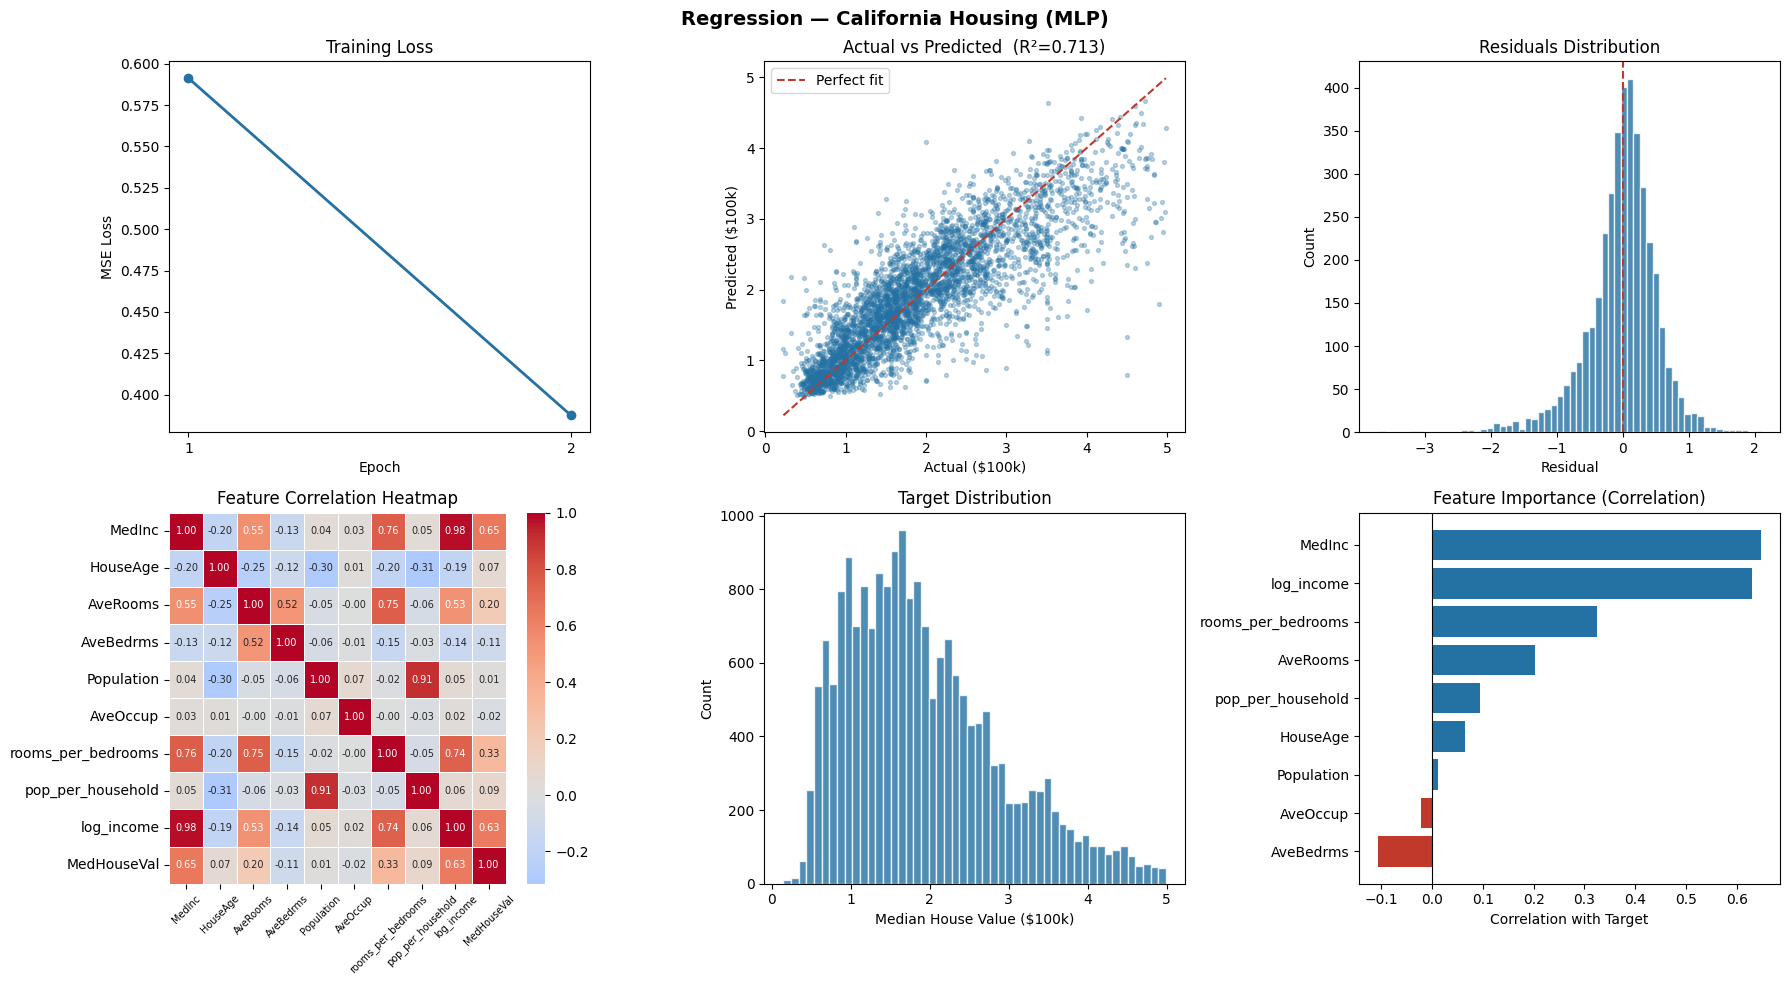

Plots saved → housing_results.png


In [6]:
# ============================================================
#  REGRESSION — California Housing (Tabular)
#  Dataset : sklearn California Housing (20,640 samples)
#  Model   : MLP
#  UI      : Gradio (HuggingFace Spaces ready, no API keys)
#
#  HOW TO RUN
#  ----------
#  Step 1 → Run BLOCK 1 to train and save model.pth
#  Step 2 → Run BLOCK 2 to launch the Gradio UI
#
#  pip install torch gradio scikit-learn pandas seaborn matplotlib joblib
# ============================================================


# ╔══════════════════════════════════════════════════════════════╗
# ║  —> TRAINING & SAVING MODEL WEIGHTS                 ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Imports ──────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Config ───────────────────────────────────────────────────
EPOCHS        = 2           # ← change epochs
BATCH_SIZE    = 64          # ← change batch size
LEARNING_RATE = 1e-3        # ← change learning rate
TEST_SIZE     = 0.2
MODEL_PATH    = "housing_model.pth"
SCALER_PATH   = "housing_scaler.pkl"
FEATURE_PATH  = "housing_features.pkl"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Load Dataset ─────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df      = housing.frame.copy()
print(f"Raw shape: {df.shape}")
print(df.describe().round(2))

# ── Tabular Feature Engineering ──────────────────────────────
# Remove outliers (tabular-specific step)
df = df[df["MedHouseVal"] < 5.0]
df = df[df["AveRooms"] < 20]

# Derived features
df["rooms_per_bedrooms"]  = df["AveRooms"]   / (df["AveBedrms"]  + 1e-5)
df["pop_per_household"]   = df["Population"] / (df["AveOccup"]   + 1e-5)
df["high_income"]         = (df["MedInc"] > 5.0).astype(int)
df["log_income"]          = np.log1p(df["MedInc"])

FEATURE_COLS = [c for c in df.columns if c != "MedHouseVal"]
X = df[FEATURE_COLS].values.astype(np.float32)
y = df["MedHouseVal"].values.astype(np.float32)
print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Save scaler and feature names for UI
joblib.dump(scaler,       SCALER_PATH)
joblib.dump(FEATURE_COLS, FEATURE_PATH)
print(f"Scaler saved → {SCALER_PATH}")
print(f"Features saved → {FEATURE_PATH}")

X_tr = torch.tensor(X_train, dtype=torch.float32)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_te = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

# ── Model ────────────────────────────────────────────────────
class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            # ── LAYER 1 ──────────────────────────────────────
            nn.Linear(input_dim, 128),  # ← change units: 64, 256
            nn.BatchNorm1d(128),        # ← remove to disable BatchNorm
            nn.ReLU(),                  # ← swap: nn.ELU() | nn.LeakyReLU(0.1) | nn.GELU()
            nn.Dropout(0.2),            # ← change dropout rate
            # ── LAYER 2 ──────────────────────────────────────
            nn.Linear(128, 64),         # ← change units
            nn.BatchNorm1d(64),         # ← remove to disable BatchNorm
            nn.ReLU(),                  # ← swap activation
            nn.Dropout(0.2),            # ← change dropout rate
            # ── LAYER 3 ──────────────────────────────────────
            nn.Linear(64, 32),          # ← change units
            nn.ReLU(),                  # ← swap activation
            # ── ADD LAYERS HERE ──────────────────────────────
            # nn.Linear(32, 16), nn.ReLU(),
            # ── OUTPUT ───────────────────────────────────────
            nn.Linear(32, 1)            # no activation — raw regression output
        )
    def forward(self, x): return self.net(x)

model = RegressionMLP(input_dim=X_train.shape[1]).to(DEVICE)
print(model)

# ── Loss & Optimizer ─────────────────────────────────────────
criterion = nn.MSELoss()                                        # ← swap: nn.HuberLoss() | nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)   # ← swap: optim.SGD | optim.RMSprop

# ── Training Loop ────────────────────────────────────────────
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, total = 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * X_b.size(0)
        total        += X_b.size(0)
    train_losses.append(running_loss / total)
    print(f"Epoch [{epoch}/{EPOCHS}]  MSE: {train_losses[-1]:.4f}  RMSE: {train_losses[-1]**0.5:.4f}")

# ── Save Weights ─────────────────────────────────────────────
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim"       : X_train.shape[1],
    "feature_cols"    : FEATURE_COLS,
}, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

# ── Evaluation ───────────────────────────────────────────────
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds.flatten())
        all_targets.extend(y_b.numpy().flatten())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

mse  = mean_squared_error(all_targets, all_preds)
rmse = mse ** 0.5
mae  = mean_absolute_error(all_targets, all_preds)
r2   = r2_score(all_targets, all_preds)
print(f"\nMSE:{mse:.4f}  RMSE:{rmse:.4f}  MAE:{mae:.4f}  R²:{r2:.4f}")

# ── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Regression — California Housing (MLP)", fontsize=14, fontweight="bold")
c1, c2 = "#2471A3", "#C0392B"

axes[0,0].plot(range(1, EPOCHS+1), train_losses, marker="o", color=c1, lw=2)
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("MSE Loss")
axes[0,0].set_title("Training Loss"); axes[0,0].set_xticks(range(1, EPOCHS+1))

axes[0,1].scatter(all_targets, all_preds, alpha=0.3, s=8, color=c1)
lims = [min(all_targets.min(), all_preds.min()), max(all_targets.max(), all_preds.max())]
axes[0,1].plot(lims, lims, "--", color=c2, lw=1.5, label="Perfect fit")
axes[0,1].set_xlabel("Actual ($100k)"); axes[0,1].set_ylabel("Predicted ($100k)")
axes[0,1].set_title(f"Actual vs Predicted  (R²={r2:.3f})"); axes[0,1].legend()

residuals = all_preds - all_targets
axes[0,2].hist(residuals, bins=60, color=c1, edgecolor="white", alpha=0.8)
axes[0,2].axvline(0, color=c2, linestyle="--", lw=1.5)
axes[0,2].set_xlabel("Residual"); axes[0,2].set_ylabel("Count")
axes[0,2].set_title("Residuals Distribution")

corr_cols = ["MedInc","HouseAge","AveRooms","AveBedrms","Population",
             "AveOccup","rooms_per_bedrooms","pop_per_household","log_income","MedHouseVal"]
corr_cols = [c for c in corr_cols if c in df.columns]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1,0], linewidths=0.4, annot_kws={"size":7})
axes[1,0].set_title("Feature Correlation Heatmap")
axes[1,0].tick_params(axis="x", rotation=45, labelsize=7)

axes[1,1].hist(df["MedHouseVal"], bins=50, color=c1, edgecolor="white", alpha=0.8)
axes[1,1].set_xlabel("Median House Value ($100k)")
axes[1,1].set_ylabel("Count"); axes[1,1].set_title("Target Distribution")

target_corr = df[corr_cols].corr()["MedHouseVal"].drop("MedHouseVal").sort_values()
bar_colors  = [c2 if v < 0 else c1 for v in target_corr]
axes[1,2].barh(target_corr.index, target_corr.values, color=bar_colors)
axes[1,2].axvline(0, color="black", lw=0.8)
axes[1,2].set_xlabel("Correlation with Target")
axes[1,2].set_title("Feature Importance (Correlation)")

plt.tight_layout()
plt.savefig("housing_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved → housing_results.png")

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  —> LOAD WEIGHTS & LAUNCH GRADIO UI                 ║
# ║  Enter house features → model predicts median value        ║
# ║  HuggingFace Spaces compatible                              ║
# ╚══════════════════════════════════════════════════════════════╝

import gradio as gr
import joblib, torch, torch.nn as nn, numpy as np, pandas as pd

MODEL_PATH   = "housing_model.pth"
SCALER_PATH  = "housing_scaler.pkl"
FEATURE_PATH = "housing_features.pkl"

# ── Recreate architecture ─────────────────────────────────────
class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),       nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,  32),       nn.ReLU(),
            nn.Linear(32,  1)
        )
    def forward(self, x): return self.net(x)

# ── Load weights & artefacts ─────────────────────────────────
ckpt         = torch.load(MODEL_PATH, map_location="cpu")
input_dim    = ckpt["input_dim"]
feature_cols = ckpt["feature_cols"]

model = RegressionMLP(input_dim)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

scaler = joblib.load(SCALER_PATH)
print(f"Loaded model ({input_dim} features) from {MODEL_PATH}")

# ── Inference function ────────────────────────────────────────
def predict_house_value(med_inc, house_age, ave_rooms, ave_bedrms,
                         population, ave_occup, latitude, longitude):
    """
    Applies the same feature engineering as training,
    scales the input, and returns predicted median house value.
    """
    row = {
        "MedInc"    : med_inc,
        "HouseAge"  : house_age,
        "AveRooms"  : ave_rooms,
        "AveBedrms" : ave_bedrms,
        "Population": population,
        "AveOccup"  : ave_occup,
        "Latitude"  : latitude,
        "Longitude" : longitude,
    }
    df_row = pd.DataFrame([row])

    # Same derived features as Block 1
    df_row["rooms_per_bedrooms"] = df_row["AveRooms"]   / (df_row["AveBedrms"]  + 1e-5)
    df_row["pop_per_household"]  = df_row["Population"] / (df_row["AveOccup"]   + 1e-5)
    df_row["high_income"]        = (df_row["MedInc"] > 5.0).astype(int)
    df_row["log_income"]         = np.log1p(df_row["MedInc"])

    # Align to training feature order
    for col in feature_cols:
        if col not in df_row.columns:
            df_row[col] = 0.0
    df_row = df_row[feature_cols]

    X = scaler.transform(df_row.values.astype(np.float32))
    X_t = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        pred = model(X_t).item()

    pred_usd = max(pred * 100_000, 0)
    return (
        f"### 🏠 Predicted Median House Value\n\n"
        f"**${pred_usd:,.0f}**  ({pred:.3f} × $100k)\n\n"
        f"---\n"
        f"*Based on MLP trained on California Housing dataset.*"
    )

# ── Gradio Interface ──────────────────────────────────────────
with gr.Blocks(title="California Housing Price Predictor") as demo:
    gr.Markdown(
        "## 🏠 California Housing Price Predictor\n"
        "Enter district-level housing features to predict the **median house value**."
    )
    with gr.Row():
        with gr.Column():
            med_inc    = gr.Slider(0.5,  15.0, value=3.87,  step=0.1,  label="Median Income (tens of thousands $)")
            house_age  = gr.Slider(1,    52,   value=28,    step=1,    label="House Age (years)")
            ave_rooms  = gr.Slider(1.0,  20.0, value=5.43,  step=0.1,  label="Average Rooms per House")
            ave_bedrms = gr.Slider(0.5,  5.0,  value=1.10,  step=0.05, label="Average Bedrooms per House")
        with gr.Column():
            population = gr.Slider(3,    35000, value=1425, step=10,   label="Block Population")
            ave_occup  = gr.Slider(1.0,  10.0,  value=2.82, step=0.1,  label="Average Occupants per House")
            latitude   = gr.Slider(32.0, 42.0,  value=35.6, step=0.1,  label="Latitude")
            longitude  = gr.Slider(-125.0,-114.0,value=-119.6,step=0.1,label="Longitude")

    btn    = gr.Button("Predict House Value", variant="primary")
    output = gr.Markdown()

    btn.click(
        fn=predict_house_value,
        inputs=[med_inc, house_age, ave_rooms, ave_bedrms,
                population, ave_occup, latitude, longitude],
        outputs=output
    )

    gr.Markdown(
        "> All values are district-level census averages, not individual house specs.\n\n"
        "> Model trained for 2 epochs on ~18k California housing records."
    )

demo.launch(share=False)  # share=True for public link on local machine

Loaded model (12 features) from housing_model.pth
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>